<a href="https://colab.research.google.com/github/intuition-explorer/ML-Algorithms/blob/main/banknote_UMAP_SHAP_AllClassifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
import pandas as pd
data = pd.read_csv('data_banknote_authentication.txt', header =None, names = ['variance', 'skewness', 'curtosis', 'entropy', 'class'])
print(data.shape)
print(data['class'].value_counts())
X=data.drop('class', axis=1).copy()
y=data['class'].copy()
#UMAP works better on scaled
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

(1372, 5)
class
0    762
1    610
Name: count, dtype: int64


In [ ]:
#UMAP views data as coming from underlying manifold, tries to preserve topology
#defines local neighbourhood using KNN, computes local connectivity probability=fuzzy simplicial set, then make symmetric=fuzzy simplical complex
#low D simliarity through differentiable kernel, gies lowDfuzzy membership then optimize with cross entropy

In [ ]:
import umap# Initialize UMAP
reducer = umap.UMAP(
    n_neighbors=15,  # How local vs global
    min_dist=0.1,    # Tightness of clusters
    n_components=2,  # 2D embedding
    random_state=42
)

# Fit and transform
X_umap = reducer.fit_transform(X_scaled)
#if want to run model after umap then should fit_transform training only, but here it was just visualization. This is b/c it drops features

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


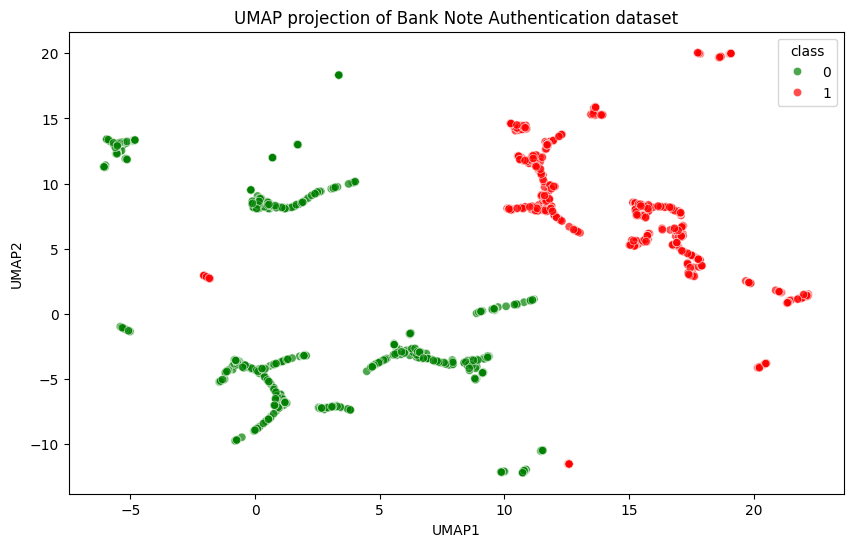

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Convert to DataFrame for plotting
umap_df = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
umap_df["class"] = y

# Plot
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=umap_df,
    x="UMAP1", y="UMAP2",
    hue="class",
    palette=["green", "red"],
    alpha=0.7
)
plt.title("UMAP projection of Bank Note Authentication dataset")
plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression, ElasticNetCV
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


Best alpha (lambda): 0.001
Best l1_ratio: 1.0
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       153
           1       0.93      1.00      0.96       122

    accuracy                           0.97       275
   macro avg       0.97      0.97      0.97       275
weighted avg       0.97      0.97      0.97       275

Confusion Matrix:
 [[144   9]
 [  0 122]]
MSE: 0.03328387003741264
R^2: 0.8651509336987393


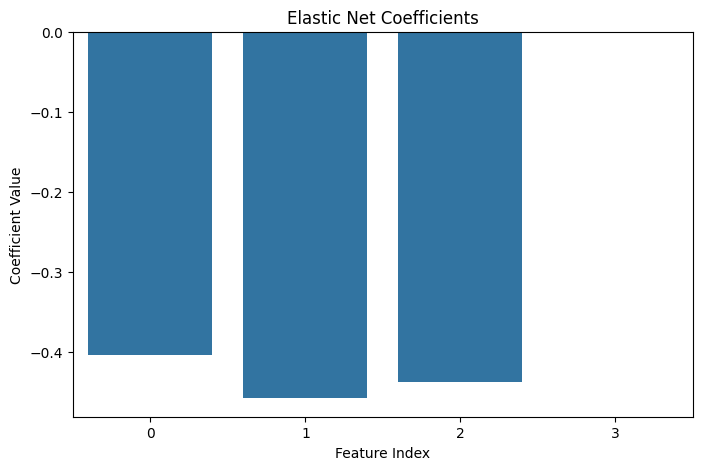

In [ ]:
# 2. Train-test split (stratified for classification balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#3. Preprocessing (scaling is CRUCIAL for Elastic Net)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Define Elastic Net model with cross-validation
# Here we use ElasticNetCV (which is linear regression-LSE) but with classification [via logistic regression flavor]
enet_cv = ElasticNetCV(
    l1_ratio=[.1, .5, .7, .9, .95, .99, 1], # range of L1/L2 mixes
    alphas=np.logspace(-3, 1, 50),          # lambda grid-this is penalty strenght
    cv=5,                                   # 5-fold CV-creates 4 to train, 1 to validate, then repeats 5 times and averages
    random_state=42
)

# Fit model
enet_cv.fit(X_train_scaled, y_train)

print("Best alpha (lambda):", enet_cv.alpha_)
print("Best l1_ratio:", enet_cv.l1_ratio_)

# 5. Predictions
y_pred = enet_cv.predict(X_test_scaled)
y_pred_class = np.where(y_pred > 0.5, 1, 0)  # classification threshold

# 6. Evaluation-classification
print(classification_report(y_test, y_pred_class))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_class))

#alpha gives you bias-variance trade off;guess Hyperparameters in general

from sklearn.metrics import mean_squared_error, r2_score #regression
print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))

# 7. Visualize coefficients
plt.figure(figsize=(8,5))
sns.barplot(x=range(X.shape[1]),  y=enet_cv.coef_) #This plot helps you understand the importance and direction of  relationship between feature and target
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Elastic Net Coefficients")
plt.show()

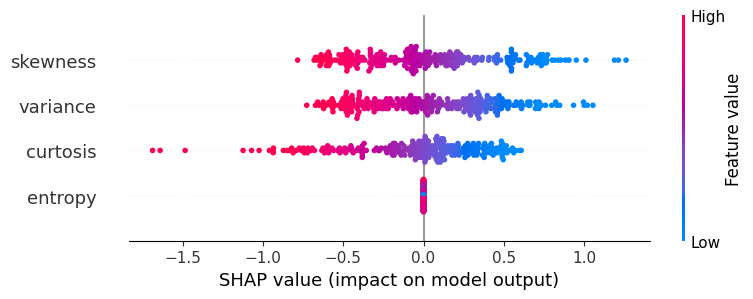

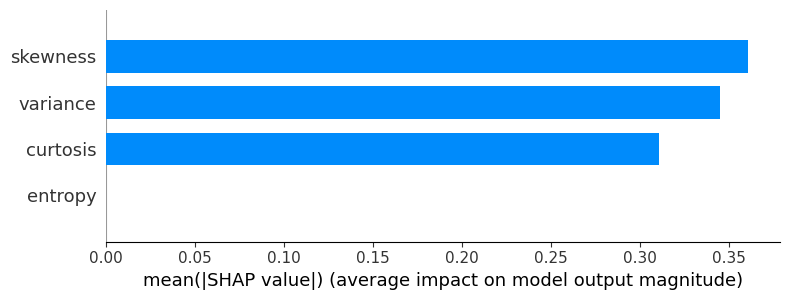

In [ ]:
#SHAP: Let’s split a model’s prediction into contributions from each feature, in a way that satisfies fairness principles.
#geometrically: SHAP = symmetrized path integral of feature contributions.Gametheoretic
#You examine this then go back to feature engineering***, very comp expensive O(n^2) use variants for big datasets
import shap

explainer = shap.Explainer(enet_cv, X_train_scaled)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

shap.summary_plot(shap_values, X_test_scaled, plot_type='bar', feature_names=X.columns)

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

svc = SVC(random_state=42, probability=True)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
  'C': [0.1,1,10,100],
  'kernel': ['linear', 'rbf'],
  'gamma': [1,0.1,0.01,0.001]
}
grid_search = GridSearchCV(svc, param_grid, cv=cv, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)
print("Best parameters:", grid_search.best_params_)
scores = cross_val_score(svc, X_train_scaled, y_train, cv=cv, scoring='accuracy')


Best parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
svc=SVC(C=10, gamma=0.1, kernel='rbf', random_state =22, probability=True)
svc.fit(X_train_scaled, y_train)
y_pred = svc.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275

Confusion Matrix:
 [[153   0]
 [  0 122]]


  0%|          | 0/275 [00:00<?, ?it/s]

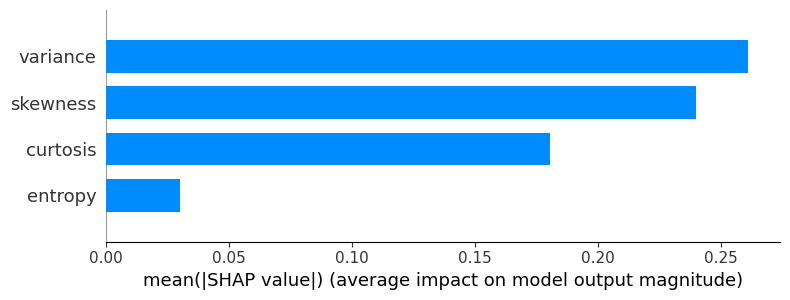

In [ ]:
import shap
estimator = shap.KernelExplainer(lambda x: svc.predict_proba(x)[:, 1], shap.sample(X_train_scaled,100)) #recommended shap.sample(data,K) in case of slower
#lambda function serves as models predict function: takes in x and returns predicted probability from svc, [:,1] selects for second class
shap_values = estimator.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", feature_names=X.columns)

In [ ]:
print(svc.predict_proba)
print(lambda x: svc.predict_proba(x))

<bound method BaseSVC.predict_proba of SVC(C=10, gamma=0.1, probability=True, random_state=22)>
<function <lambda> at 0x7d8c46f8cea0>


In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
  'C': [0.1,1,10,100],
  'penalty': ['l2'],
  'solver': ['liblinear', 'lbfgs', 'newton-cholesky']
}
from sklearn.model_selection import RandomizedSearchCV
grid_search = RandomizedSearchCV(lr, param_grid, cv=cv, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)
print("Best parameters:", grid_search.best_params_)

Best parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}


In [ ]:
# Best model already refit on the entire training set, this is saved implicitly
best_model = grid_search.best_estimator_

from sklearn.metrics import accuracy_score
# Evaluate on test set
y_pred = best_model.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.9854545454545455
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       153
           1       0.97      1.00      0.98       122

    accuracy                           0.99       275
   macro avg       0.98      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275

Confusion Matrix:
 [[149   4]
 [  0 122]]


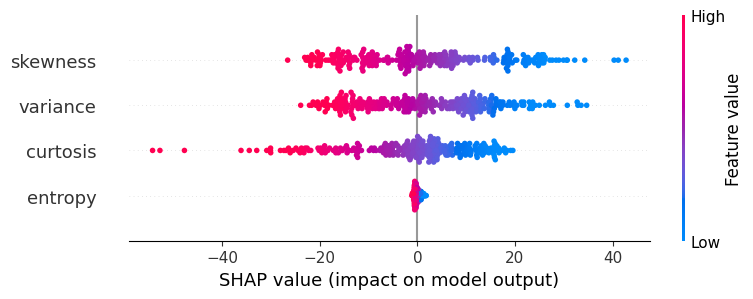

In [ ]:
import shap
explainer = shap.LinearExplainer(best_model, X_train_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

In [ ]:
#KNN, NB, DT =classifiers as well not used
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import numpy as np
import pandas as pd

#try to tune all 3 and test = Define models + parameter grids
models_and_params = [
    (
        "knn",
        KNeighborsClassifier(),
        {
            "knn__n_neighbors": [3, 5, 7, 9],
            "knn__weights": ["uniform", "distance"],
            "knn__p": [1, 2]  # 1=Manhattan, 2=Euclidean
        },
    ),
    (
        "nb",
        GaussianNB(),
        {
            "nb__var_smoothing": np.logspace(-9, -3, 7)
        },
    ),
    (
        "dt",
        DecisionTreeClassifier(random_state=42),
        {
            "dt__max_depth": [None, 5, 10, 20],
            "dt__min_samples_split": [2, 5, 10],
            "dt__min_samples_leaf": [1, 2, 4],
            "dt__criterion": ["gini", "entropy"]
        },
    ),
]

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model, params in models_and_params:
  pipe = Pipeline([(name,model)])
  search = RandomizedSearchCV(pipe, param_distributions=params, random_state= 22, cv=cv, n_jobs=-1, scoring ='accuracy')
  search.fit(X_train_scaled, y_train)
  results[name] = {
        "best_params": search.best_params_,
        "best_cv_score": search.best_score_,
        "test_score": search.score(X_test_scaled, y_test), # Use X_test_scaled for scoring
    }
df_results = pd.DataFrame(results).T
print(df_results)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 7 is smaller than n_iter=10. Running 7 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


                                           best_params best_cv_score  \
knn  {'knn__weights': 'distance', 'knn__p': 2, 'knn...      0.998182   
nb                        {'nb__var_smoothing': 1e-09}      0.841449   
dt   {'dt__min_samples_split': 2, 'dt__min_samples_...      0.988153   

    test_score  
knn        1.0  
nb    0.858182  
dt    0.989091  


In [ ]:

# Make sure pandas shows full dicts
pd.set_option("display.max_colwidth", None)

for model_name, row in df_results.iterrows():
    print(f"\n=== Model: {model_name} ===")

    # 1️⃣ Best parameters
    print("Best parameters:", row["best_params"])

    # 2️⃣ Refit model on full training set
    # Extract model type from pipeline step name
    best_params = row["best_params"]

    # Map step name to sklearn class
    if model_name == "knn":
        model_class = KNeighborsClassifier
    elif model_name == "nb":
        model_class = GaussianNB
    elif model_name == "dt":
        model_class = DecisionTreeClassifier

    # Remove the step prefix for initialization
    cleaned_params = {k.split("__")[1]: v for k, v in best_params.items()}
    final_model = model_class(**cleaned_params)

    # Need to fit the model on the training data again
    final_model.fit(X_train_scaled, y_train)


    # 3️⃣ Predictions
    y_pred = final_model.predict(X_test_scaled)


    # 4️⃣ Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # 5️⃣ Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)



=== Model: knn ===
Best parameters: {'knn__weights': 'distance', 'knn__p': 2, 'knn__n_neighbors': 3}

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275

Confusion Matrix:
 [[153   0]
 [  0 122]]

=== Model: nb ===
Best parameters: {'nb__var_smoothing': np.float64(1e-09)}

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       153
           1       0.85      0.83      0.84       122

    accuracy                           0.86       275
   macro avg       0.86      0.86      0.86       275
weighted avg       0.86      0.86      0.86       275

Confusion Matrix:
 [[135  18]
 [ 21 101]]

=== Model: dt ===
Best parameters:

In [ ]:
for model, row in df_results.iterrows():
    print(f"\nModel: {model}")
    for k, v in row["best_params"].items():
        print(f"  {k}: {v}")


Model: knn
  knn__weights: distance
  knn__p: 2
  knn__n_neighbors: 3

Model: nb
  nb__var_smoothing: 1e-09

Model: dt
  dt__min_samples_split: 2
  dt__min_samples_leaf: 2
  dt__max_depth: 20
  dt__criterion: entropy
